<a href="https://colab.research.google.com/github/gabiuxo/Algoritmos-de-Aprendizaje-Automatico/blob/main/Practica_Viernes_Tema9_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica del viernes - Correlación y benchmark de modelos

**Nombre:** Gabriel Elizondo Martinez  
**Matrícula:** AL07009102  
**Tema 9 - Parte 2:** Correlaciones, visualización y optimización


## Reto 1. Cálculo manual de correlación de Pearson

Utilicé las sumas proporcionadas para calcular el coeficiente de correlación de Pearson.


In [1]:
import numpy as np

# define the provided sums
sum_products = 9.5
sum_squared_x = 5.0
sum_squared_y = 18.75

# calculate the pearson correlation coefficient
pearson_r = sum_products / np.sqrt(sum_squared_x * sum_squared_y)

print(f"Coeficiente de correlación de Pearson: {pearson_r:.3f}")


Coeficiente de correlación de Pearson: 0.981


Obtuve **r = 0.981**, lo que indica una correlación lineal positiva muy fuerte. Cuando una variable aumenta, la otra también tiende a aumentar. Por este resultado, revisaría si ambas variables aportan información redundante antes de utilizarlas juntas en un modelo.


## Reto 2. Filtrado automatizado de alta multicolinealidad

Calculé la matriz de correlación absoluta y revisé únicamente su triángulo superior para evitar comparar dos veces el mismo par de variables.


In [2]:
import pandas as pd

# create the simulated numeric dataset
df_sim = pd.DataFrame({
    "A": [1, 2, 3, 4, 5],
    "B": [1.1, 2.0, 3.1, 4.2, 4.9],
    "C": [5, 4, 3, 2, 1],
})

# calculate the absolute correlation matrix
corr_matrix = df_sim.corr().abs()
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# find unique pairs with correlation at or above 0.90
high_correlations = []
for row in upper_triangle.index:
    for column in upper_triangle.columns:
        value = upper_triangle.loc[row, column]
        if pd.notna(value) and value >= 0.90:
            high_correlations.append((row, column, round(float(value), 4)))

print("Matriz de correlación absoluta:")
print(corr_matrix.round(4))
print("\nPares altamente correlacionados:", high_correlations)


Matriz de correlación absoluta:
        A       B       C
A  1.0000  0.9975  1.0000
B  0.9975  1.0000  0.9975
C  1.0000  0.9975  1.0000

Pares altamente correlacionados: [('A', 'B', 0.9975), ('A', 'C', 1.0), ('B', 'C', 0.9975)]


Encontré tres pares con correlación absoluta mayor o igual a 0.90: **A-B, A-C y B-C**. Aunque A y C se relacionan de forma negativa, al utilizar el valor absoluto su correlación es 1. Estas variables son candidatas a revisión por posible redundancia, pero no las eliminaría sin comprobar primero el efecto sobre el modelo.


## Reto 3. Proyección y visualización 3D con PCA

Estandaricé las variables del conjunto Iris y apliqué PCA con tres componentes. Después construí un DataFrame con la proyección y la clase de cada observación.


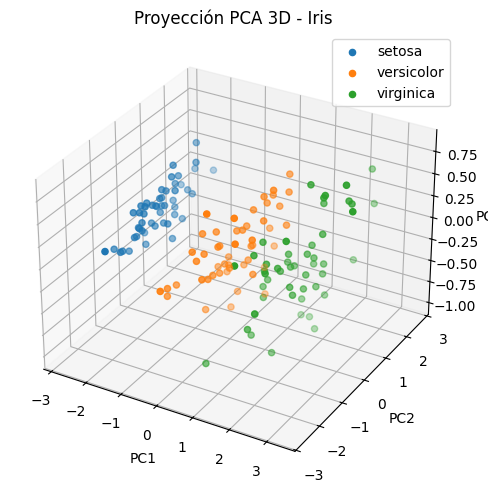

Forma del espacio proyectado en 3D: (150, 3)
Varianza acumulada: 99.48%

Primeras filas del DataFrame:
        PC1       PC2       PC3  Class
0 -2.264703  0.480027  0.127706      0
1 -2.080961 -0.674134  0.234609      0
2 -2.364229 -0.341908 -0.044201      0
3 -2.299384 -0.597395 -0.091290      0
4 -2.389842  0.646835 -0.015738      0


In [3]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# load and standardize the iris dataset
iris = load_iris()
x_scaled = StandardScaler().fit_transform(iris.data)

# project the data into three principal components
pca_3 = PCA(n_components=3)
z_3d = pca_3.fit_transform(x_scaled)

# create a dataframe with the projected components
pca_3d_df = pd.DataFrame(z_3d, columns=["PC1", "PC2", "PC3"])
pca_3d_df["Class"] = iris.target

# display the three-dimensional projection
fig = plt.figure(figsize=(7, 5))
axis = fig.add_subplot(111, projection="3d")

for class_id, class_name in enumerate(iris.target_names):
    class_data = pca_3d_df[pca_3d_df["Class"] == class_id]
    axis.scatter(
        class_data["PC1"],
        class_data["PC2"],
        class_data["PC3"],
        label=class_name,
    )

axis.set_xlabel("PC1")
axis.set_ylabel("PC2")
axis.set_zlabel("PC3")
axis.set_title("Proyección PCA 3D - Iris")
axis.legend()
plt.tight_layout()
plt.show()

print("Forma del espacio proyectado en 3D:", z_3d.shape)
print(f"Varianza acumulada: {pca_3.explained_variance_ratio_.sum() * 100:.2f}%")
print("\nPrimeras filas del DataFrame:")
print(pca_3d_df.head())


La proyección quedó con **150 observaciones y 3 componentes**. Los tres componentes conservaron aproximadamente **99.48% de la varianza total**. La gráfica permite observar la distribución de las especies en un espacio reducido.


## Reto 4. Pipeline baseline

Separé el conjunto simulado en entrenamiento y prueba. Después construí un Pipeline con estandarización y regresión logística para mantener el preprocesamiento dentro del flujo del modelo.


In [4]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# create and split the classification dataset
x, y = make_classification(
    n_samples=200,
    n_features=10,
    random_state=42,
)
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

# create and fit the baseline pipeline
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(random_state=42)),
])
baseline_pipeline.fit(x_train, y_train)
baseline_accuracy = baseline_pipeline.score(x_test, y_test)

print(f"Precisión del pipeline baseline: {baseline_accuracy:.4f}")


Precisión del pipeline baseline: 0.7500


El pipeline baseline obtuvo una precisión de **0.7500** en el conjunto de prueba. Este resultado funciona como referencia para comparar después otras rutas de simplificación bajo la misma partición.


## Reto 5. DataFrame de benchmark

Organicé los resultados simulados en un DataFrame y los ordené de mayor a menor según su F1-score.


In [5]:
# define the simulated benchmark results
benchmark_results = [
    {"Route": "Baseline", "F1": 0.88, "Time_s": 0.05},
    {"Route": "RFECV", "F1": 0.89, "Time_s": 0.45},
    {"Route": "PCA 95%", "F1": 0.85, "Time_s": 0.02},
]

# create and sort the benchmark dataframe
benchmark_df = pd.DataFrame(benchmark_results)
benchmark_df = benchmark_df.sort_values(by="F1", ascending=False)

print(benchmark_df.to_string(index=False))


   Route   F1  Time_s
   RFECV 0.89    0.45
Baseline 0.88    0.05
 PCA 95% 0.85    0.02


**RFECV** obtuvo el mejor F1-score con **0.89**, aunque también tuvo el mayor tiempo de ejecución. El baseline quedó muy cerca con 0.88 y fue más rápido. PCA fue la opción más rápida, pero presentó el F1-score más bajo. Si mi prioridad fuera el rendimiento predictivo, elegiría RFECV; si necesitara una solución más simple y rápida, mantendría el baseline.
